In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Global Constants

In [2]:
start_date = "2023-02-01"
end_date = "2024-02-01"

coins = ["BTC-USD", "ETH-USD"] 

intervals = ['1d', '5d']

rsi_upper_threshold = 70
rsi_lower_threshold = 30

risk_free_rate = 0.04

### Generate 5d

In [3]:
def convert_to_5d(coin: str, data: pd.DataFrame):
    data.index = pd.to_datetime(data.index)
    
    data_5d = data.resample('5D').agg({
        ('Open', coin): 'first',
        ('High', coin): 'max',
        ('Low', coin): 'min',
        ('Close', coin): 'last',
        ('Volume', coin): 'sum'
    }).dropna()

    return data_5d

## Part 1

### Bollinger Bands

In [4]:
def calculate_bollinger_bands(data:pd.DataFrame, interval, window:int=20, coefficient:float=2):
    if interval == '5d':
        window = int(window / 5)

    data['SMA'] =  data["Close"].rolling(window).mean()
    data['STD'] =  data["Close"].rolling(window).std()
    
    data['Upper Bound'] = data['SMA'] + (data['STD'] * coefficient)
    data['Middle Bound'] = data['SMA']
    data['Lower Bound'] = data['SMA'] - (data['STD'] * coefficient)
    
    return data

### Keltner Channels

In [5]:
def calculate_tr(data:pd.DataFrame):
    value1 = data["High"] - data["Low"]
    value2 = abs(data["High"] - data["Close"].shift(1))
    value3 = abs(data["Low"] - data["Close"].shift(1))

    data["TR"] = np.maximum(value1, value2, value3)

    return data

def calculate_atr(data:pd.DataFrame, period:int=14):
    data = calculate_tr(data)
    data["ATR"] = np.nan

    initial_atr = data["TR"].iloc[:period].mean()
    c = 0
    for i in data.index:
        if c == 14:
            break
        data.loc[i, "ATR"] = initial_atr
        c += 1
    
    if not data.index.is_monotonic_increasing:
        data = data.reset_index(drop=True)

    cc = 0
    prev_atr = data.loc[data.index[0], "ATR"]
    for i in data.index:
        if cc < 14:
            cc += 1
            continue
        
        current_tr = data.loc[i, "TR"]
        v = ((prev_atr * (period - 1)) + current_tr) / period
        data.loc[i, "ATR"] = v.values
        prev_atr = v
    
    return data

def calculate_keltner_channel(data:pd.DataFrame, interval, period:int=14, coefficient:float=2):
    if interval == '5d':
        period = int(period / 5)
    data = calculate_atr(data, period)
    
    data["Upper Channel"] = data["SMA"] + (data["ATR"] * coefficient)
    data["Lower Channel"] = data["SMA"] - (data["ATR"] * coefficient)

    return data

### RSI

In [6]:
def calculate_rsi(data:pd.DataFrame, window=14):
    delta = data["Close"] - data["Close"].shift(1)
    gain = delta.where(delta > 0, 0).rolling(window=window).mean()
    loss = delta.where(delta < 0, 0).rolling(window=window).mean()
    rs = gain / abs(loss)
    data["RSI"] = 100 - (100 / (1 + rs)) 
    return data

### Plot 

In [7]:
def plot_data(data:pd.DataFrame, coin, equity):
    plt.figure(figsize=(14, 7))
    plt.plot(data['Close'], label='Close Price', color='black')
    plt.plot(data['Upper Bound'], label='Bollinger Upper Band', color='red', linestyle='--')
    plt.plot(data['Lower Bound'], label='Bollinger Lower Band', color='red', linestyle='--')
    plt.plot(data['Upper Channel'], label='Keltner Upper Channel', color='blue', linestyle='--')
    plt.plot(data['Lower Channel'], label='Keltner Lower Channel', color='blue', linestyle='--')
    
    buy_signals = data[data['Buy'] == True]
    sell_signals = data[data['Sell'] == True]
    plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy Signal', s=100)
    plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell Signal', s=100)
    
    plt.title(f'Trading Signals for {coin}')
    plt.legend(loc='best')
    plt.show()

    fig, axs = plt.subplots(1, 2, figsize=(14, 3), sharex=False)
    # Plot RSI
    axs[0].plot(data['RSI'], label='RSI', color='yellow')
    axs[0].set_title(f'RSI Signals for {coin}')
    axs[0].legend(loc='best')

    # Plot Equity
    axs[1].plot(equity, label='Equity', color='violet')
    axs[1].set_title(f'Equity Status for {coin}')
    axs[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

### Backtest

In [8]:
def Backtest(data:pd.DataFrame, initial_capital:float):
    balance = initial_capital
    count = 0  
    equity = []
    index = 0
    in_buy = False
    in_sell = False
    in_price = -1
    signals = []
    for i, row in data.iterrows():
        if index < 20:
            index += 1
            equity.append(count * row["Close"] + balance)
            signals.append(0)
            continue 

        if row["Close"].values < row["Lower Channel"].values and row["Close"].values < row["Lower Bound"].values and row["RSI"].values[0] < rsi_lower_threshold:  #Buy
            if in_buy:
                signals.append(0)
                equity.append(count * row["Close"] + balance)
                continue

            if in_sell:
                balance = count * (2 * in_price - row["Close"])
                count = 0

            in_price = row["Close"]
            in_buy = True
            in_sell = False
            signals.append(1)
            print(f"Buy at {i}")
            count = balance / row["Close"]
            balance = 0
            equity.append(count * row["Close"])

        elif row["Close"].values > row["Upper Channel"].values and row["Close"].values > row["Upper Bound"].values and row["RSI"].values[0] > rsi_upper_threshold: #Sell
            if in_sell:
                signals.append(0)
                equity.append(count * ((2 * in_price - row["Close"])) + balance)
                continue

            if in_buy:
                balance = count * row["Close"] 
                count = 0

            in_price = row["Close"]
            in_sell = True
            in_buy = False
            signals.append(-1)
            print(f"Sell at {i}")
            count = balance / row["Close"]
            balance = 0
            equity.append(count * ((2 * in_price - row["Close"])) + balance)

        else:
            if in_sell:
                equity.append(count * ((2 * in_price - row["Close"])) + balance)
            else:
                equity.append(count * row["Close"] + balance)
            
            signals.append(0)
        
        index += 1

    data["Buy"] = [sig == 1 for sig in signals]
    data["Sell"] = [sig == -1 for sig in signals]
 
    return equity, data

### Parameters

In [9]:
def net_profit(equity: pd.Series, initial_capital: float) -> float:
    return equity.iloc[-1] - initial_capital

def max_drawdown(equity: pd.Series) -> float:
    pv = equity.cummax()
    return ((equity - pv) / pv).min() * 100 

def drawdown_period(equity: pd.Series) -> int:
    cummax = -1
    cummax_t = -1
    max_drawdown_t = 0
    drawdown_period = None
    for i in range(len(equity)):
        if equity[i] >= cummax:
            cummax = equity[i]
            drawdown_days = (equity.index[i] - equity.index[cummax_t]).days
            if drawdown_days > max_drawdown_t:
                drawdown_period = (equity.index[cummax_t], equity.index[i])
            max_drawdown_t = max(max_drawdown_t, drawdown_days)  
            cummax_t = i

    print(f"\nMax Drawdown Period is from ", end='')
    print(f"{drawdown_period[0].year}/{drawdown_period[0].month}/{drawdown_period[0].day} ", end='')
    print(f"to {drawdown_period[1].year}/{drawdown_period[1].month}/{drawdown_period[1].day}", end='')
    return max_drawdown_t

def sharpe_ratio(equity: pd.Series) -> float:
    daily_returns = equity.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    annualized_return = excess_returns.mean() * 252
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    return annualized_return / annualized_volatility

def sortino_ratio(equity: pd.Series) -> float:
    daily_returns = equity.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    downside_risk = daily_returns[daily_returns < 0].std() * np.sqrt(252)
    annualized_return = excess_returns.mean() * 252
    return annualized_return / downside_risk

### Driver (Default Values)

[*********************100%***********************]  1 of 1 completed


Buy at 2023-03-09 00:00:00+00:00
Sell at 2023-03-17 00:00:00+00:00
Buy at 2023-08-17 00:00:00+00:00
Sell at 2023-10-21 00:00:00+00:00


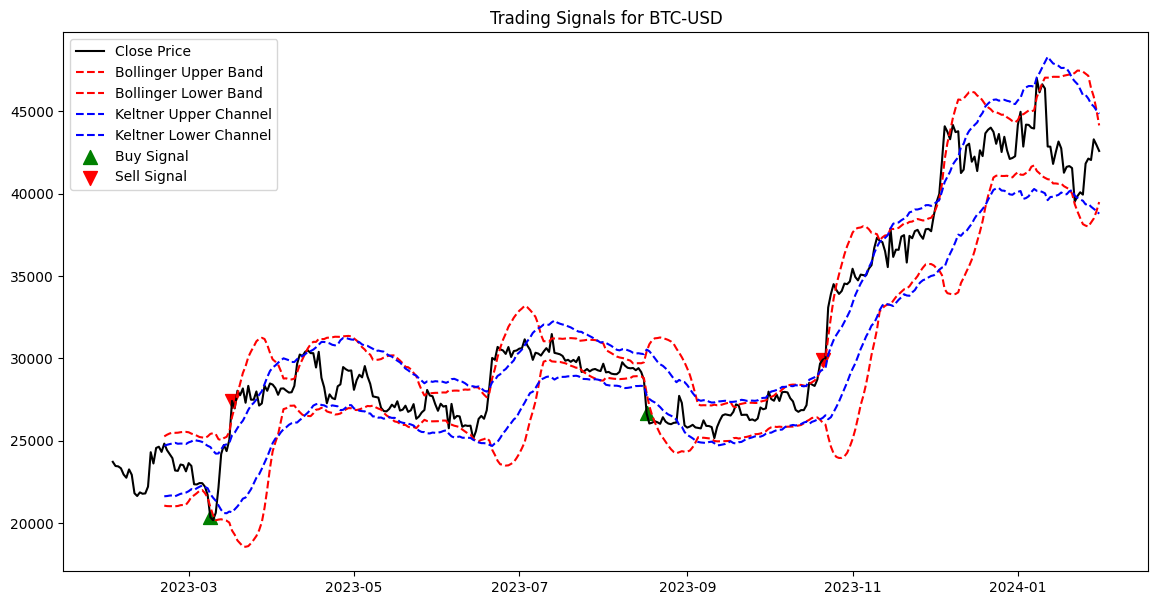

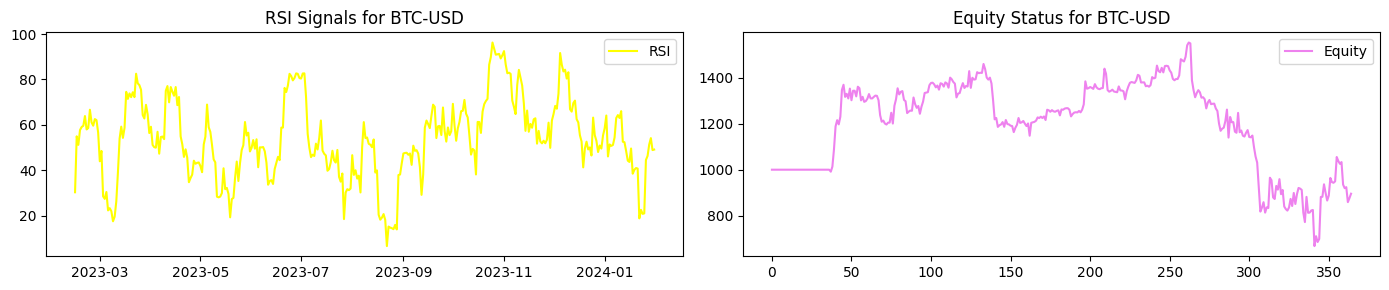

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\3707699095.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)


Net Profit: -104.41
Max Drawdown: -57.0%
Max Drawdown Period is from 2023/6/14 to 2023/10/16
Drawdown Period: 124
Sharpe Ratio: 0.07
Sortino Ratio: 0.09




[*********************100%***********************]  1 of 1 completed


Buy at 2023-03-09 00:00:00+00:00
Sell at 2023-04-13 00:00:00+00:00
Buy at 2023-06-14 00:00:00+00:00
Sell at 2023-10-01 00:00:00+00:00


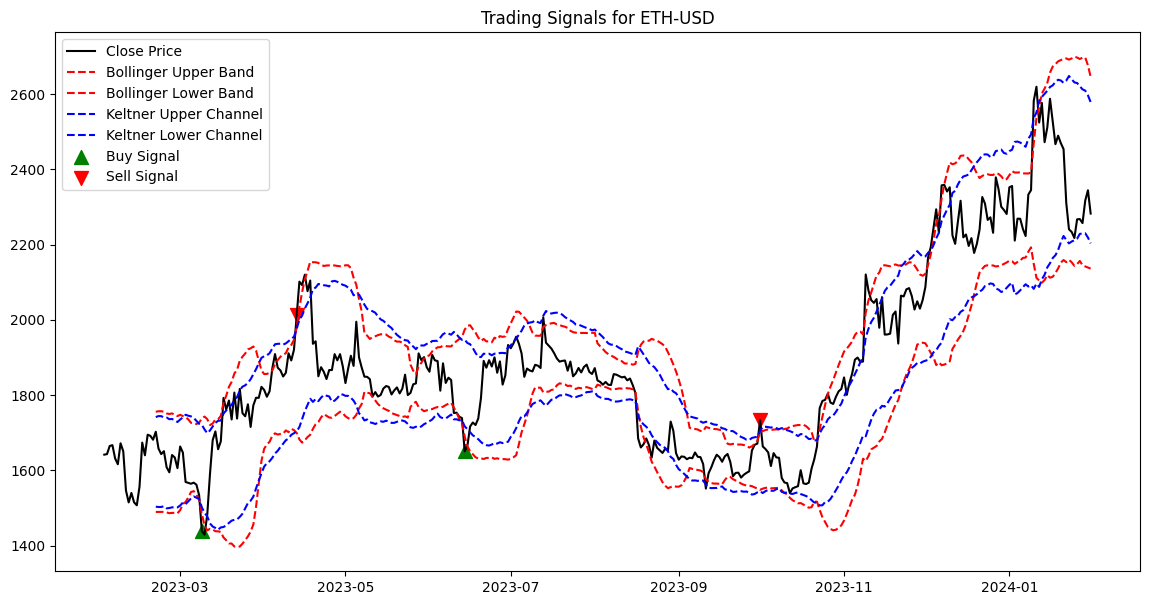

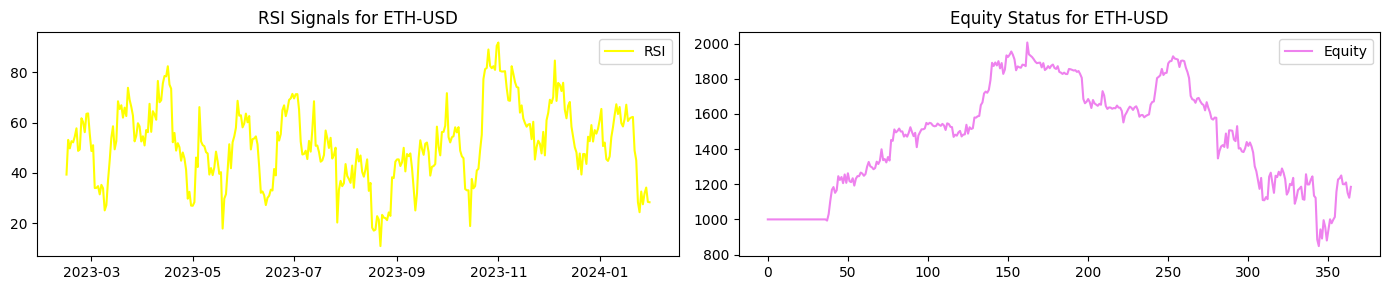

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\3707699095.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)
[*********************100%***********************]  1 of 1 completed


Net Profit: 185.18
Max Drawdown: -57.74%
Max Drawdown Period is from 2023/5/13 to 2023/6/10
Drawdown Period: 28
Sharpe Ratio: 0.41
Sortino Ratio: 0.49




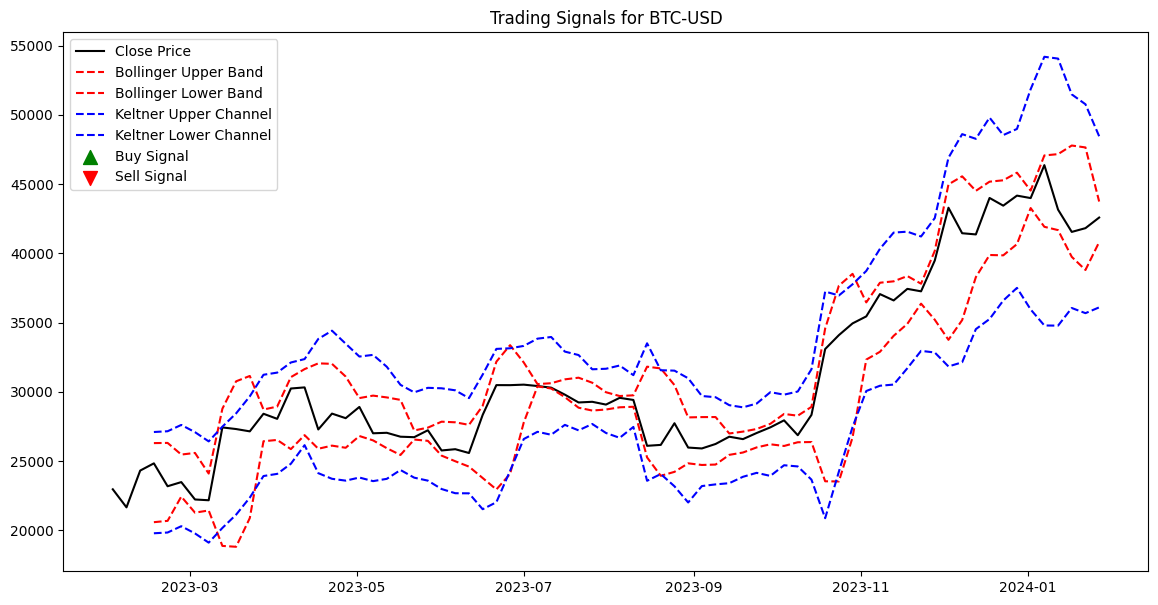

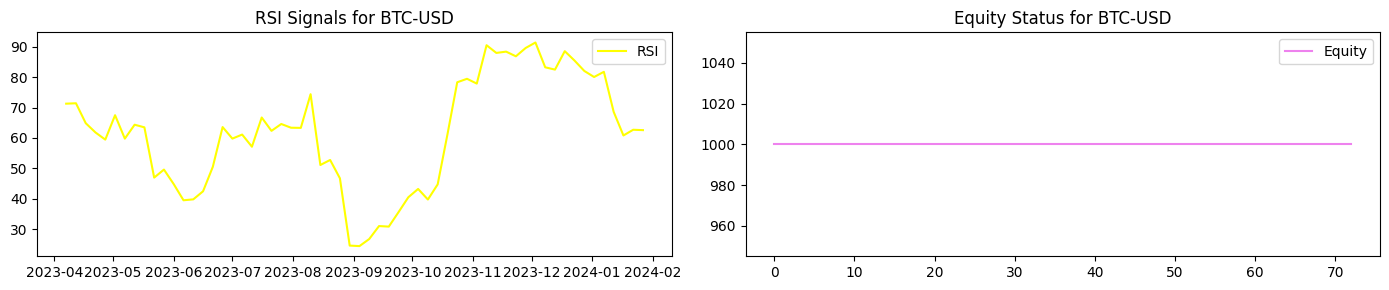

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\3707699095.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)
[*********************100%***********************]  1 of 1 completed


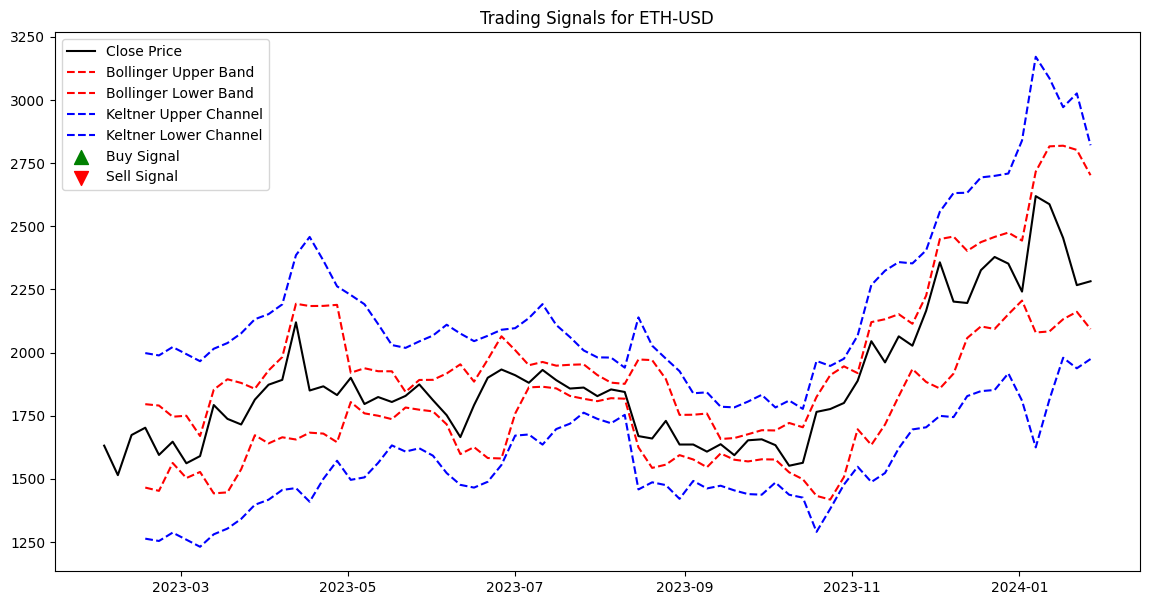

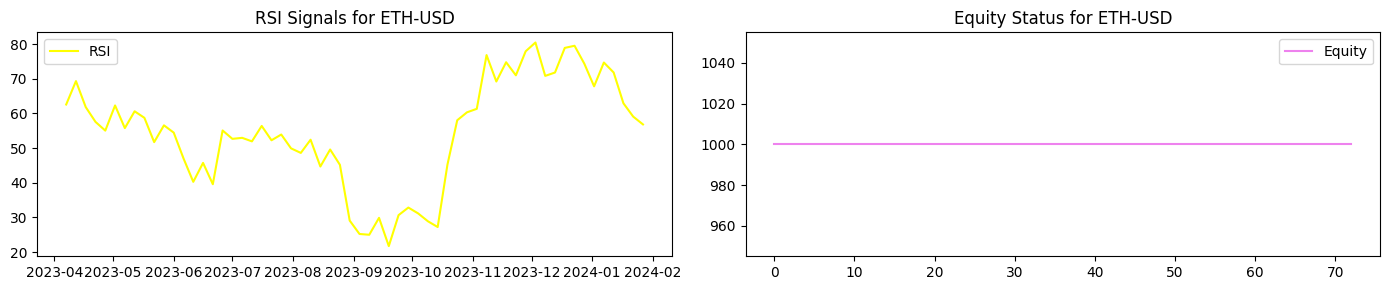

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\3707699095.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)


In [10]:
data = {}
for interval in intervals:
    for coin in coins:
        data[coin] = yf.download(coin, start=start_date, end=end_date, interval='1d')
        if interval == '5d':
            data[coin] = convert_to_5d(coin, data[coin])
        _data = data[coin].copy(deep=True)
        _data = calculate_bollinger_bands(_data, interval)
        _data = calculate_keltner_channel(_data, interval)
        _data = calculate_rsi(_data)
        equity, _data = Backtest(_data, initial_capital=1000)
        plot_data(_data, coin, equity)
        equity = pd.Series(equity, index=_data.index)
        equity = pd.Series([float(x) for x in equity.values], index=_data.index)
        if interval == '1d':
            print(f"Net Profit: {round(net_profit(equity, initial_capital=1000), 2)}\n", end=50*"=")
            print(f"\nMax Drawdown: {round(max_drawdown(equity), 2)}%\n", end=50*"=")
            print(f"\nDrawdown Period: {round(drawdown_period(equity), 2)}\n", end=50*"=")
            print(f"\nSharpe Ratio: {round(sharpe_ratio(equity), 2)}\n", end=50*"=")
            print(f"\nSortino Ratio: {round(sortino_ratio(equity), 2)}\n", end=50*"=")
        print("\n\n")

### Driver (New Values)

[*********************100%***********************]  1 of 1 completed

Buy at 2023-03-09 00:00:00+00:00
Sell at 2023-06-21 00:00:00+00:00
Buy at 2023-08-17 00:00:00+00:00
Sell at 2023-10-23 00:00:00+00:00


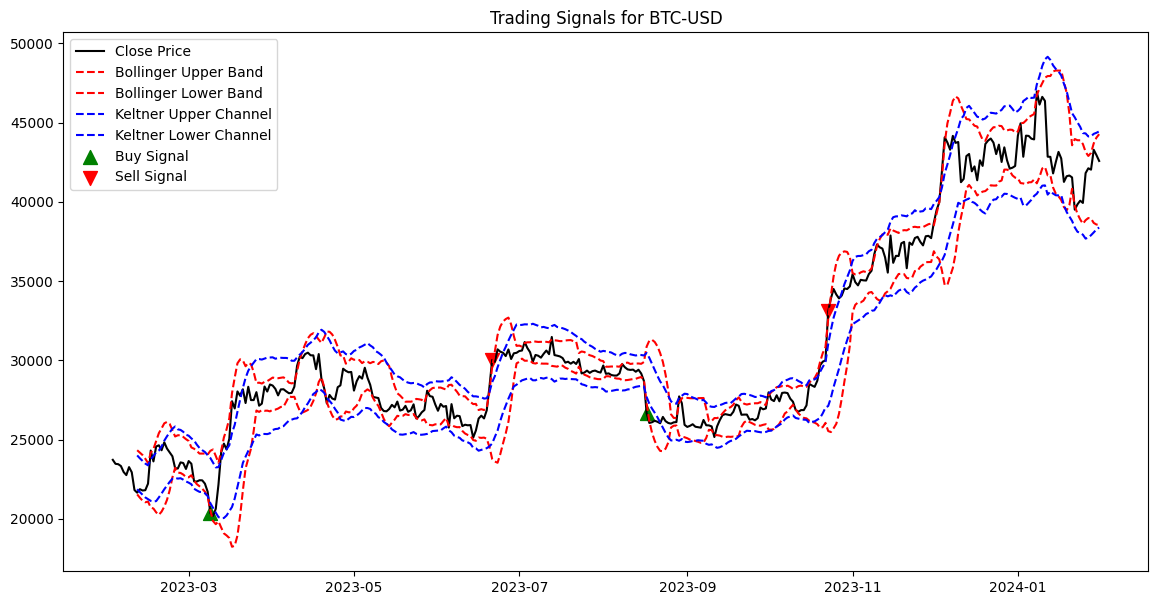

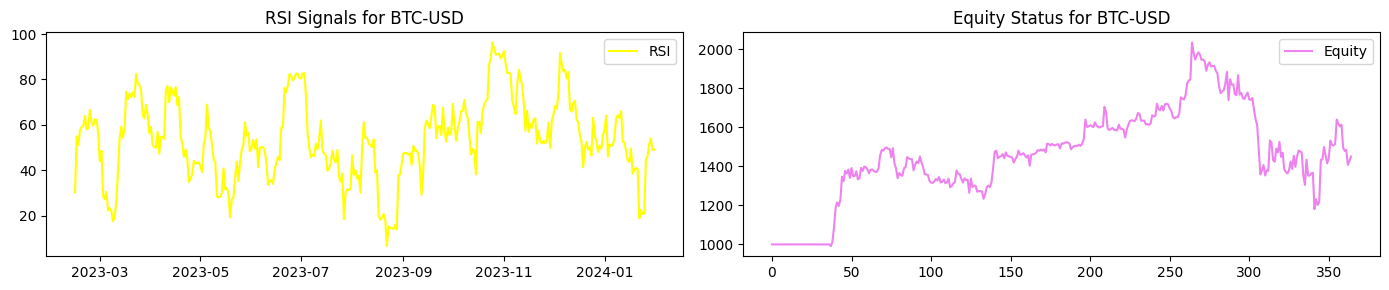

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\1105653848.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)
[*********************100%***********************]  1 of 1 completed


Net Profit: 450.66
Max Drawdown: -41.96%
Max Drawdown Period is from 2023/4/14 to 2023/7/24
Drawdown Period: 101
Sharpe Ratio: 0.71
Sortino Ratio: 0.99


Buy at 2023-03-09 00:00:00+00:00
Sell at 2023-04-14 00:00:00+00:00
Buy at 2023-08-17 00:00:00+00:00
Sell at 2023-10-01 00:00:00+00:00


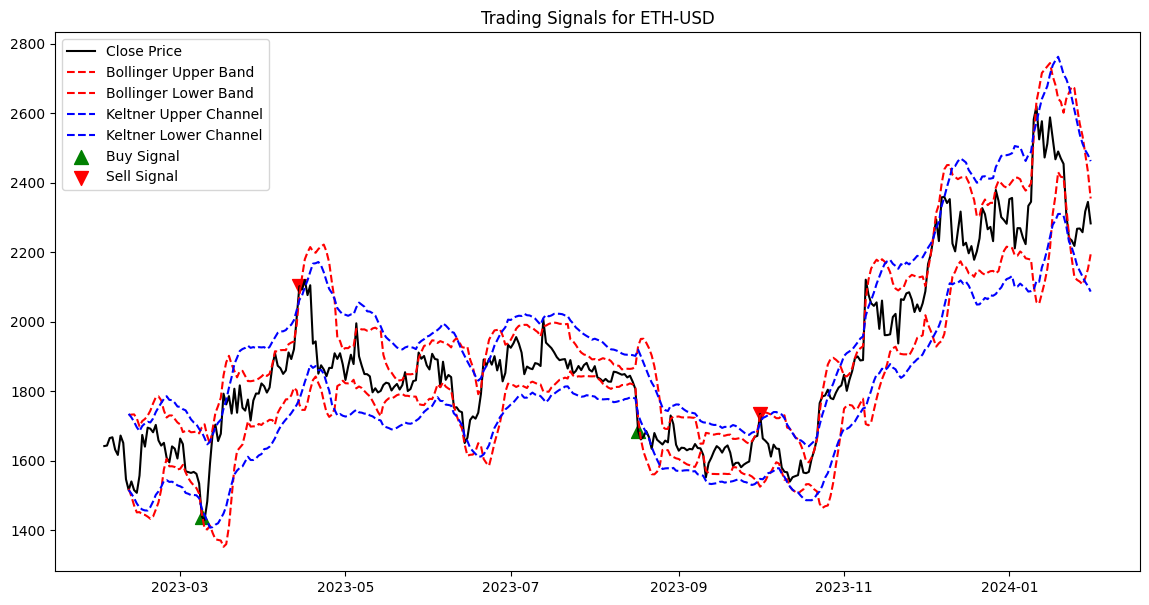

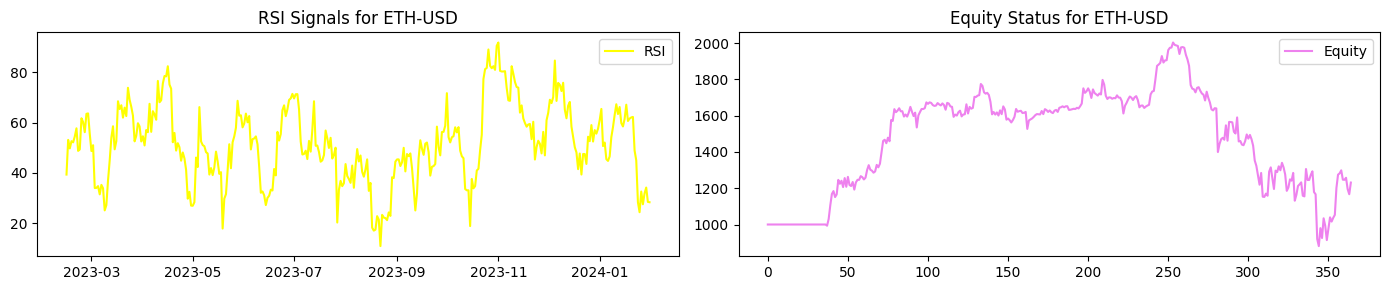

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\1105653848.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)
[*********************100%***********************]  1 of 1 completed


Net Profit: 231.17
Max Drawdown: -56.02%
Max Drawdown Period is from 2023/6/14 to 2023/8/29
Drawdown Period: 76
Sharpe Ratio: 0.46
Sortino Ratio: 0.54




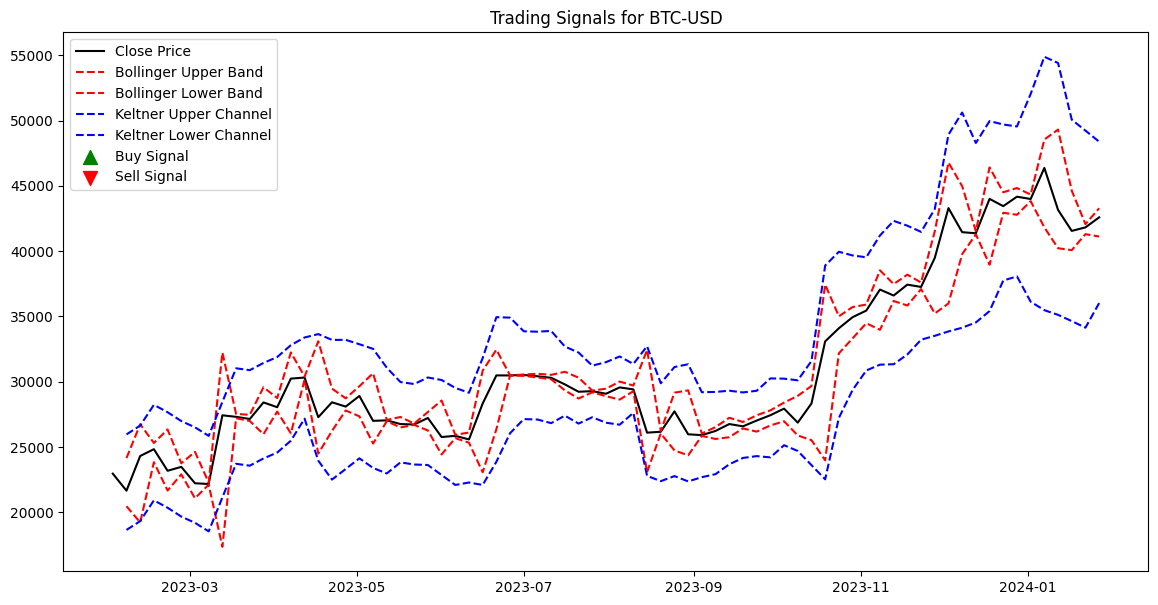

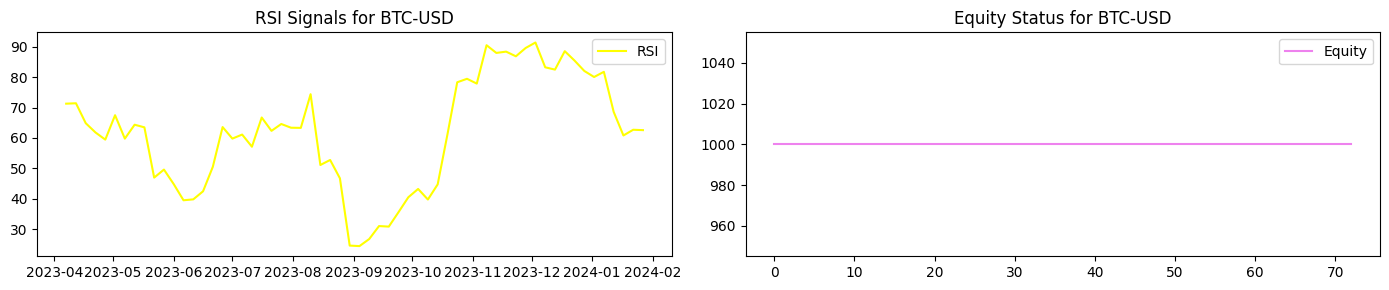

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\1105653848.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)
[*********************100%***********************]  1 of 1 completed


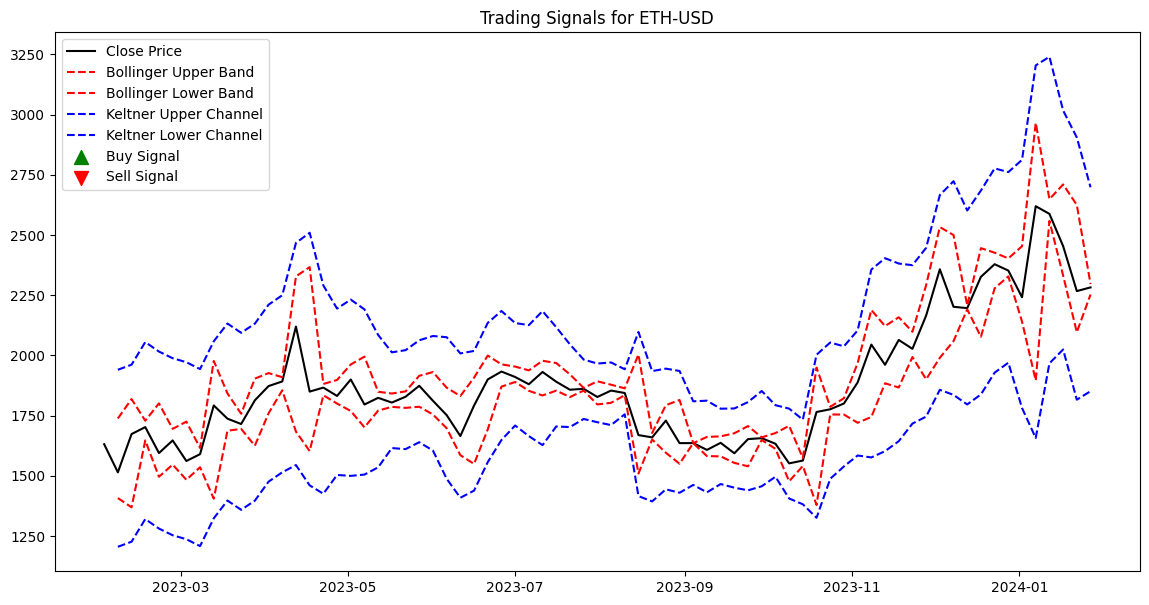

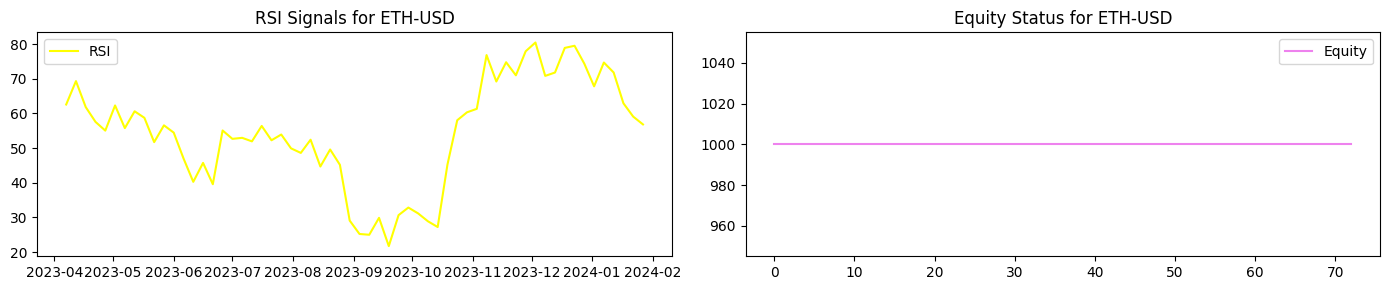

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\1105653848.py:15: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)


In [11]:
data = {}
for interval in intervals:
    for coin in coins:
        data[coin] = yf.download(coin, start=start_date, end=end_date, interval='1d')
        if interval == '5d':
            data[coin] = convert_to_5d(coin, data[coin])
        _data = data[coin].copy(deep=True)
        _data = calculate_bollinger_bands(_data, interval=interval, window=10)
        _data = calculate_keltner_channel(_data,  interval=interval)
        _data = calculate_rsi(_data)
        ### az ru nemudar bekhun !!!
        equity, _data = Backtest(_data, initial_capital=1000)
        plot_data(_data, coin, equity)
        equity = pd.Series(equity, index=_data.index)
        equity = pd.Series([float(x) for x in equity.values], index=_data.index)
        if interval == '1d':
            print(f"Net Profit: {round(net_profit(equity, initial_capital=1000), 2)}\n", end=50*"=")
            print(f"\nMax Drawdown: {round(max_drawdown(equity), 2)}%\n", end=50*"=")
            print(f"\nDrawdown Period: {round(drawdown_period(equity), 2)}\n", end=50*"=")
            print(f"\nSharpe Ratio: {round(sharpe_ratio(equity), 2)}\n", end=50*"=")
            print(f"\nSortino Ratio: {round(sortino_ratio(equity), 2)}\n", end=50*"=")
        print("\n\n")

## Part 2

### Plot

In [12]:
def plot_data2(data:pd.DataFrame, coin, equity):
    plt.figure(figsize=(14, 7))
    plt.plot(data['Close'], label='Close Price', color='black')
    plt.plot(data['Open'], label='Open Price', color='silver')
    plt.plot(data['Upper Bound'], label='Bollinger Upper Band', color='blue', linestyle='--')
    plt.plot(data['Lower Bound'], label='Bollinger Lower Band', color='lightblue', linestyle='--')
    
    buy_signals = data[data['Buy'] == True]
    sell_signals = data[data['Sell'] == True]
    plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', label='Buy Signal', s=100)
    plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='red', label='Sell Signal', s=100)
    
    plt.title(f'Trading Signals for {coin}')
    plt.legend(loc='best')
    plt.show()

    plt.figure(figsize=(14, 7))
    plt.plot(equity, label='Equity', color='violet')
    plt.title(f'Equity Status for {coin}')
    plt.legend(loc='best')
    plt.show()

### Backtest

In [13]:
def Backtest2(data:pd.DataFrame, initial_capital:float):
    balance = initial_capital
    count = 0  
    equity = []
    index = 0
    in_buy, in_sell = False, False
    in_price = -1
    signals = []
    make_buy, make_sell = False, False
    for i, row in data.iterrows():
        if index < 20:
            index += 1
            equity.append(count * row["Close"] + balance)
            signals.append(0)
            continue 

        if row["Close"].values < row["Lower Bound"].values:  #Buy Condition
            if not in_buy:
                make_buy = True

            signals.append(0)
            if in_sell:
                equity.append(count * ((2 * in_price - row["Close"])) + balance)
            else:
                equity.append(count * row["Close"] + balance)

        elif row["Close"].values > row["Upper Bound"].values: #Sell Condition
            if not in_sell:
                make_sell = True
            
            signals.append(0)
            if in_sell:
                equity.append(count * ((2 * in_price - row["Close"])) + balance)
            else:
                equity.append(count * row["Close"] + balance)

        elif make_buy:  # Buy in the next day
            if in_sell:
                balance = count * (2 * in_price - row["Open"])
                count = 0

            in_price = row["Open"]
            in_buy = True
            in_sell = False
            signals.append(1)
            print(f"Buy at {i}")
            count = balance / row["Open"]
            balance = 0
            equity.append(count * row["Open"])  # Buying Day: Price=Open
            make_buy = False

        elif make_sell: # Sell in the next day
            if in_buy:
                balance = count * row["Open"] 
                count = 0

            in_price = row["Open"]
            in_sell = True
            in_buy = False
            signals.append(-1)
            print(f"Sell at {i}")
            count = balance / row["Open"]
            balance = 0
            equity.append(count * ((2 * in_price - row["Open"])) + balance) # Selling Day: Price=Open
            make_sell = False

        else:
            if in_sell:
                equity.append(count * ((2 * in_price - row["Close"])) + balance)
            else:
                equity.append(count * row["Close"] + balance)
            
            signals.append(0)
        
        index += 1

    data["Buy"] = [sig == 1 for sig in signals]
    data["Sell"] = [sig == -1 for sig in signals]
 
    return equity, data

### Driver

[*********************100%***********************]  1 of 1 completed


Buy at 2023-03-11 00:00:00+00:00
Sell at 2023-03-18 00:00:00+00:00
Buy at 2023-06-12 00:00:00+00:00
Sell at 2023-07-14 00:00:00+00:00
Buy at 2023-08-20 00:00:00+00:00
Sell at 2023-10-02 00:00:00+00:00


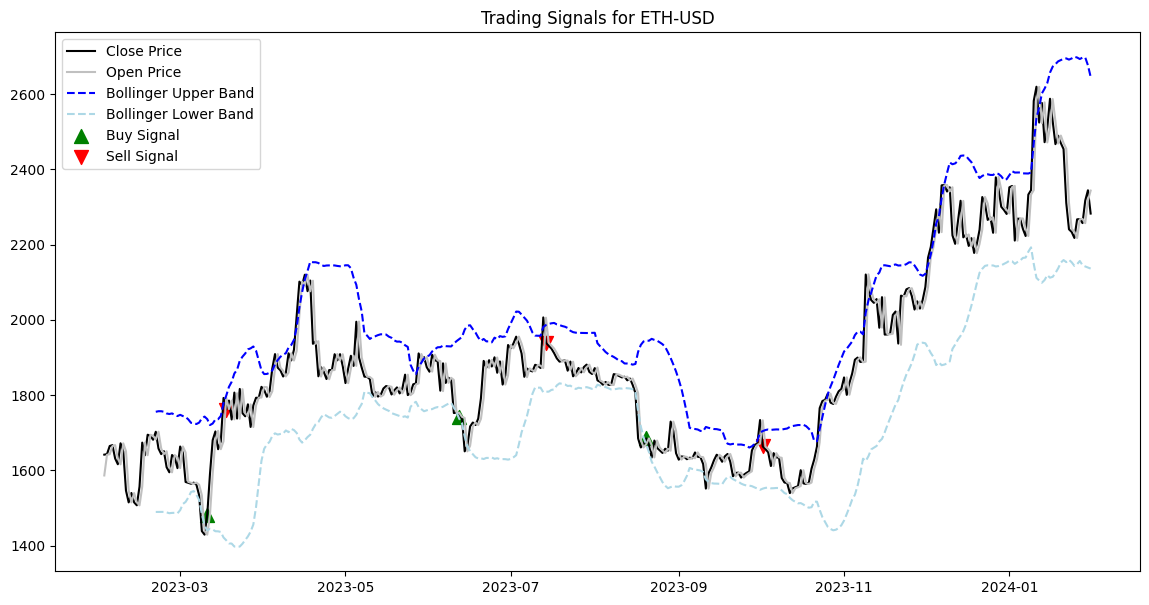

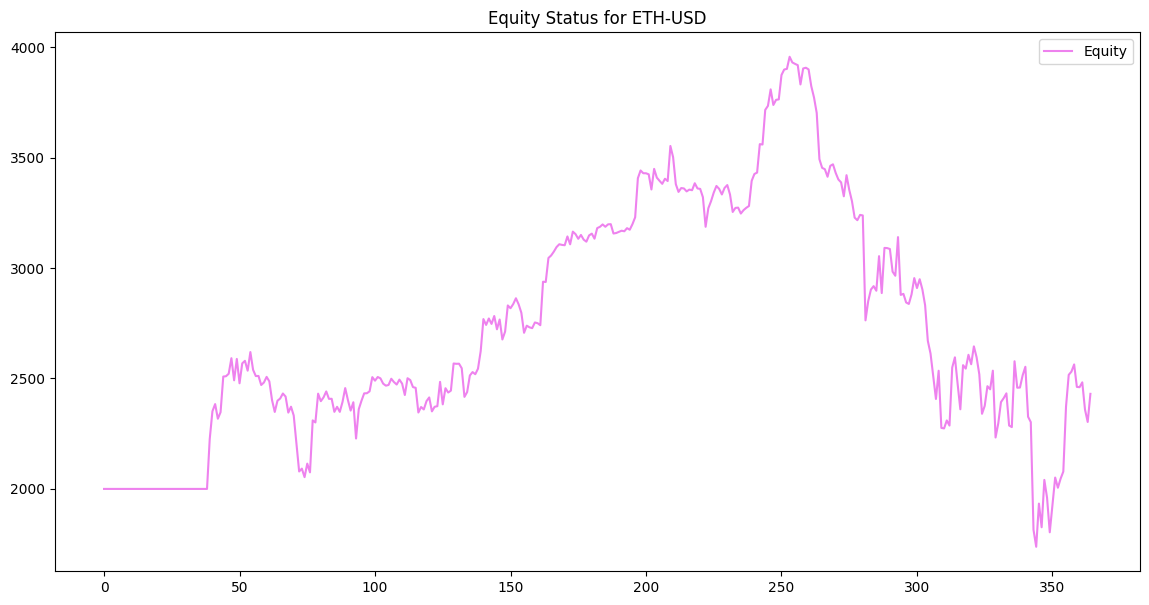

Net Profit: 430.35
Max Drawdown: -56.06%
Max Drawdown Period is from 2023/3/27 to 2023/6/20
Drawdown Period: 85
Sharpe Ratio: 0.45
Sortino Ratio: 0.54

C:\Users\efnhm\AppData\Local\Temp\ipykernel_16856\162700470.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  equity = pd.Series([float(x) for x in equity.values], index=_data.index)


In [16]:
data = {}
coin = 'ETH-USD'
data[coin] = yf.download(coin, start=start_date, end=end_date, interval='1d')
_data = data[coin].copy(deep=True)
_data = calculate_bollinger_bands(_data, interval='1d')
equity, _data = Backtest2(_data, initial_capital=2000)
plot_data2(_data, coin, equity)
equity = pd.Series(equity, index=_data.index)
equity = pd.Series([float(x) for x in equity.values], index=_data.index)
print(f"Net Profit: {round(net_profit(equity, initial_capital=2000), 2)}\n", end=50*"=")
print(f"\nMax Drawdown: {round(max_drawdown(equity), 2)}%\n", end=50*"=")
print(f"\nDrawdown Period: {round(drawdown_period(equity), 2)}\n", end=50*"=")
print(f"\nSharpe Ratio: {round(sharpe_ratio(equity), 2)}\n", end=50*"=")
print(f"\nSortino Ratio: {round(sortino_ratio(equity), 2)}\n", end=50*"=")